In [66]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage import exposure
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [67]:
# -----------------------------
# 2. Dataset configuration
# -----------------------------
DATASET_PATH = "dataset"
classes = ["Normal", "stone"]
label_map = {label: idx for idx, label in enumerate(classes)}
IMG_SIZE = (256, 256)

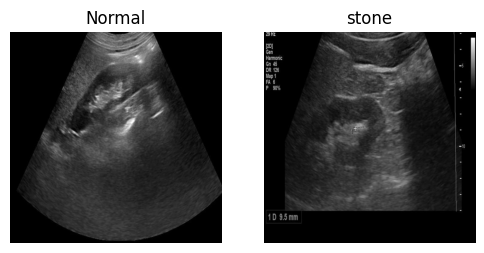

In [68]:
plt.figure(figsize=(6,3))

for i, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.show()


In [69]:
# -----------------------------
# 3. Load and preprocess images
# -----------------------------
def load_and_preprocess_images(dataset_path, classes, img_size=(256,256)):
    images, labels = [], []
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Grayscale → Resize → Crop → Median Filter → Normalize
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, img_size)
            img_masked = img_resized[10:-10, 10:-10]
            img_filtered = cv2.medianBlur(img_masked, 5)
            img_normalized = img_filtered / 255.0
            images.append(img_normalized)
            labels.append(label_map[class_name])
    return np.array(images), np.array(labels)

print("Loading images...")
images, labels = load_and_preprocess_images(DATASET_PATH, classes, IMG_SIZE)
print(f"Loaded {len(images)} images: {np.sum(labels==0)} Normal, {np.sum(labels==1)} Stone")


Loading images...
Loaded 2000 images: 1000 Normal, 1000 Stone


In [70]:
# -----------------------------
# 4. Feature extraction (GLCM + Gabor entropy)
# -----------------------------
def extract_features(images):
    features_list = []
    for img in images:
        # Gabor entropy
        gabor_real, _ = gabor(img, frequency=0.6)
        entropy_val = -np.sum(gabor_real * np.log2(gabor_real + 1e-10))

        # GLCM features
        glcm_features = []
        distances = [1,3,5]
        angles = [0, np.pi/4, np.pi/2, np.pi]
        img_uint8 = (img*255).astype(np.uint8)
        for d in distances:
            for a in angles:
                glcm = graycomatrix(img_uint8, distances=[d], angles=[a], levels=256, symmetric=True, normed=True)
                glcm_features.extend([
                    graycoprops(glcm, 'energy')[0,0],
                    graycoprops(glcm, 'correlation')[0,0],
                    graycoprops(glcm, 'contrast')[0,0],
                    graycoprops(glcm, 'homogeneity')[0,0],
                    graycoprops(glcm, 'dissimilarity')[0,0]
                ])
        features_list.append([entropy_val] + glcm_features)
    return np.array(features_list)

print("Extracting features...")
features = extract_features(images)
print("Features shape:", features.shape)

Extracting features...


C:\Users\Somaya Ahmad\AppData\Local\Temp\ipykernel_19632\344863322.py:9: RuntimeWarning: invalid value encountered in log2
  entropy_val = -np.sum(gabor_real * np.log2(gabor_real + 1e-10))


Features shape: (2000, 61)


In [71]:
# -----------------------------
# 5. Handle NaNs and remove duplicates
# -----------------------------
imputer = SimpleImputer(strategy='mean')
features = imputer.fit_transform(features)

df = pd.DataFrame(features)
df['Label'] = labels
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop('Label', axis=1).values
y = df['Label'].values
print("Shape after removing duplicates:", X.shape)

Shape after removing duplicates: (1842, 60)


c:\Users\Somaya Ahmad\cv-projects\Kidney_stone_detection-\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [0]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [80]:
feature_names = [f"F{i+1}" for i in range(X.shape[1])]

df = pd.DataFrame(X, columns=feature_names)
df["Label"] = y
df["Class"] = df["Label"].map({0:"Normal", 1:"Stone"})

df.head()
print("Number of duplicate rows:", df.duplicated().sum())
print("Null values:\n", df.isnull().sum())
# X: feature matrix (samples × features)
# y: labels (0 / 1)

print("X shape:", X.shape)




Number of duplicate rows: 0
Null values:
 F1       0
F2       0
F3       0
F4       0
F5       0
        ..
F58      0
F59      0
F60      0
Label    0
Class    0
Length: 62, dtype: int64
X shape: (1842, 60)


In [74]:
Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (X < lower_bound) | (X > upper_bound)
outlier_count = np.sum(outlier_mask)

print("Total outlier values:", outlier_count)


Total outlier values: 2502


In [76]:
# -----------------------------
# 6. Split data: train/val/test (70/15/15)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Train: (1289, 60) Validation: (276, 60) Test: (277, 60)


In [82]:
# Create feature names
num_features = X.shape[1]
feature_names = [f"F{i+1}" for i in range(num_features)]

df = pd.DataFrame(X, columns=feature_names)
df["Label"] = y
df["Class"] = df["Label"].map({0: "Normal", 1: "stone"})

print(df.head())

         F1        F2         F3        F4        F5        F6        F7  \
0  0.246504  0.993735  14.837306  0.636452  1.617797  0.243713  0.985768   
1  0.272004  0.994186  25.208132  0.644288  1.763018  0.267382  0.985652   
2  0.269964  0.991376  31.173657  0.638872  1.886206  0.265576  0.982618   
3  0.296479  0.992568  47.879354  0.601748  2.463235  0.292277  0.985054   
4  0.268853  0.995993  55.236423  0.547036  2.907032  0.264711  0.991959   

           F8        F9       F10  ...         F53       F54        F55  \
0   33.622363  0.565625  2.419719  ...  169.772709  0.379096   6.517151   
1   62.167623  0.569082  2.844853  ...  425.083021  0.363454   9.570145   
2   62.802698  0.543825  3.159710  ...  409.322364  0.338731  10.775039   
3   96.214830  0.503244  3.947777  ...  495.294336  0.329620  12.383264   
4  110.645867  0.472464  4.743033  ...  847.085553  0.315921  16.097696   

        F56       F57         F58       F59        F60  Label   Class  
0  0.219913  0.91881

In [77]:
# -----------------------------
# 7. Train SVM classifier
# -----------------------------
clf = SVC(kernel='linear', probability=True)
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [78]:
# -----------------------------
# 8. Evaluate on validation set
# -----------------------------
y_val_pred = clf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.9456521739130435
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95       150
           1       0.98      0.90      0.94       126

    accuracy                           0.95       276
   macro avg       0.95      0.94      0.94       276
weighted avg       0.95      0.95      0.95       276

Validation Confusion Matrix:
 [[148   2]
 [ 13 113]]


In [79]:
# -----------------------------
# 9. Evaluate on test set
# -----------------------------
y_test_pred = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.9422382671480144
Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       150
           1       0.97      0.90      0.93       127

    accuracy                           0.94       277
   macro avg       0.95      0.94      0.94       277
weighted avg       0.94      0.94      0.94       277

Test Confusion Matrix:
 [[147   3]
 [ 13 114]]
